# ConFit Fine-Tuning — Notebook 1: Data Exploration

This notebook downloads both raw datasets from Kaggle, loads them into DataFrames, and performs a full exploratory analysis before any extraction or training work begins.

**Datasets:**
- `snehaanbhawal/resume-dataset` — 2400+ resumes with `Category` labels
- `kshitizregmi/jobs-and-job-description` — Job titles and full JD text

**Outputs:** Understanding of class distributions, text lengths, and category overlap between the two datasets.

## Section 1 — Install and Import Dependencies

In [1]:
%pip install kagglehub -q

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USR005\OneDrive - Maersk Group\Documents\GitHub\IISC_emp_onboarding_proj\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import kagglehub
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

warnings.filterwarnings("ignore")

# Base data directory — all downloaded files land here
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")

c:\Users\USR005\OneDrive - Maersk Group\Documents\GitHub\IISC_emp_onboarding_proj\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.


## Section 2 — Download Jobs and Job Description Dataset

In [3]:
# Download latest version
jobs_path = kagglehub.dataset_download("kshitizregmi/jobs-and-job-description")

print("Path to dataset files:", jobs_path)
print("\nFiles in directory:")
for f in Path(jobs_path).iterdir():
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

100%|██████████| 1.48M/1.48M [00:01<00:00, 859kB/s]

Extracting files...
Path to dataset files: C:\Users\USR005\.cache\kagglehub\datasets\kshitizregmi\jobs-and-job-description\versions\2

Files in directory:
  job_title_des.csv  (4488.2 KB)


## Section 3 — Download Resume Dataset

In [ ]:
# Download latest version
resume_path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", resume_path)
print("\nAll files (recursive):")
for f in sorted(Path(resume_path).rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(resume_path)}  ({f.stat().st_size / 1024:.1f} KB)")

100%|██████████| 62.5M/62.5M [00:20<00:00, 3.21MB/s]

Extracting files...


Path to dataset files: C:\Users\USR005\.cache\kagglehub\datasets\snehaanbhawal\resume-dataset\versions\1

Files in directory:
  data  (0.0 KB)
  Resume  (0.0 KB)


## Section 4 — Load Datasets into DataFrames

In [ ]:
# ── Load Jobs / JD dataset ──────────────────────────────────────────────────
# Use rglob so we find CSVs even if they're in a subdirectory
jobs_csv_files = list(Path(jobs_path).rglob("*.csv"))
print("Jobs CSV files found:", [f.name for f in jobs_csv_files])

jobs_df = pd.read_csv(jobs_csv_files[0], encoding="utf-8")
print(f"\nJobs DataFrame loaded: {jobs_df.shape[0]:,} rows × {jobs_df.shape[1]} columns")
jobs_df.head(3)

Jobs CSV files found: ['job_title_des.csv']

Jobs DataFrame loaded: 2,277 rows × 3 columns


,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."


In [7]:
# ── Load Resume dataset ─────────────────────────────────────────────────────
# Use rglob — the CSV may live inside a subdirectory of the downloaded path
resume_csv_files = list(Path(resume_path).rglob("*.csv"))
print("Resume CSV files found:", [str(f.relative_to(resume_path)) for f in resume_csv_files])

resume_df = pd.read_csv(resume_csv_files[0], encoding="utf-8")
print(f"\nResume DataFrame loaded: {resume_df.shape[0]:,} rows × {resume_df.shape[1]} columns")
resume_df.head(3)

Resume CSV files found: ['Resume\\Resume.csv']

Resume DataFrame loaded: 2,484 rows × 4 columns


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Section 5 — Initial Data Exploration

In [8]:
print("=" * 60)
print("JOBS / JD DATASET")
print("=" * 60)
print(f"Shape : {jobs_df.shape}")
print(f"Columns: {list(jobs_df.columns)}")
print()
print(jobs_df.dtypes)
print()
jobs_df.describe(include="all")

JOBS / JD DATASET
Shape : (2277, 3)
Columns: ['Unnamed: 0', 'Job Title', 'Job Description']

Unnamed: 0          int64
Job Title          object
Job Description    object
dtype: object



,Unnamed: 0,Job Title,Job Description
count,2277.000000,2277,2277
unique,NaN,15,2264
top,NaN,JavaScript Developer,We are looking for skilled mobile app develope...
freq,NaN,166,2
mean,1187.974089,NaN,NaN
std,694.438444,NaN,NaN
min,0.000000,NaN,NaN
25%,585.000000,NaN,NaN
50%,1183.000000,NaN,NaN
75%,1782.000000,NaN,NaN


In [9]:
print("=" * 60)
print("RESUME DATASET")
print("=" * 60)
print(f"Shape : {resume_df.shape}")
print(f"Columns: {list(resume_df.columns)}")
print()
print(resume_df.dtypes)
print()
resume_df.describe(include="all")

RESUME DATASET
Shape : (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object



,ID,Resume_str,Resume_html,Category
count,2.484000e+03,2484,2484,2484
unique,NaN,2482,2482,24
top,NaN,FINANCE OFFICER Professional ...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY
freq,NaN,2,2,120
mean,3.182616e+07,NaN,NaN,NaN
std,2.145735e+07,NaN,NaN,NaN
min,3.547447e+06,NaN,NaN,NaN
25%,1.754430e+07,NaN,NaN,NaN
50%,2.521031e+07,NaN,NaN,NaN
75%,3.611444e+07,NaN,NaN,NaN


In [10]:
# ── Identify the key text columns robustly ─────────────────────────────────
# Jobs: find the JD text column (longest avg text among string columns)
jobs_text_col = max(
    (c for c in jobs_df.columns if jobs_df[c].dtype == object),
    key=lambda c: jobs_df[c].dropna().str.len().mean()
)
# Jobs: find the title column (shortest avg text among string columns)
jobs_title_col = min(
    (c for c in jobs_df.columns if jobs_df[c].dtype == object),
    key=lambda c: jobs_df[c].dropna().str.len().mean()
)

# Resume: Category column
resume_category_col = [c for c in resume_df.columns if "categ" in c.lower()][0]
# Resume: text column
resume_text_col = max(
    (c for c in resume_df.columns if resume_df[c].dtype == object and c != resume_category_col),
    key=lambda c: resume_df[c].dropna().str.len().mean()
)

print(f"Jobs title column  : '{jobs_title_col}'")
print(f"Jobs JD text column: '{jobs_text_col}'")
print(f"Resume text column : '{resume_text_col}'")
print(f"Resume category col: '{resume_category_col}'")

Jobs title column  : 'Job Title'
Jobs JD text column: 'Job Description'
Resume text column : 'Resume_html'
Resume category col: 'Category'


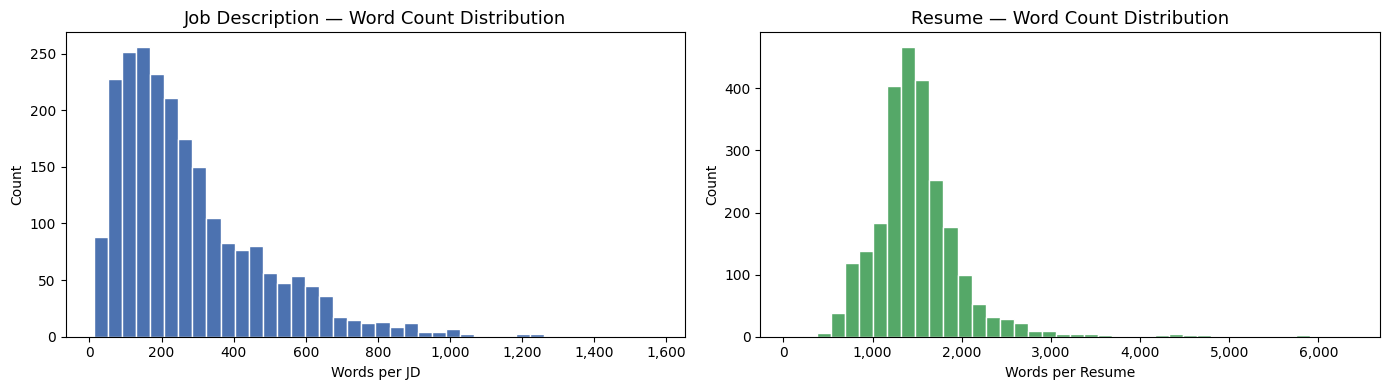


JD word count  — median: 223  |  max: 1575
Resume word cnt — median: 1439  |  max: 6375


In [11]:
# ── Text length distributions ──────────────────────────────────────────────
jobs_df["jd_len"]     = jobs_df[jobs_text_col].dropna().str.split().str.len()
resume_df["res_len"]  = resume_df[resume_text_col].dropna().str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(jobs_df["jd_len"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Job Description — Word Count Distribution", fontsize=13)
axes[0].set_xlabel("Words per JD")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(resume_df["res_len"].dropna(), bins=40, color="#55A868", edgecolor="white")
axes[1].set_title("Resume — Word Count Distribution", fontsize=13)
axes[1].set_xlabel("Words per Resume")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"\nJD word count  — median: {jobs_df['jd_len'].median():.0f}  |  max: {jobs_df['jd_len'].max():.0f}")
print(f"Resume word cnt — median: {resume_df['res_len'].median():.0f}  |  max: {resume_df['res_len'].max():.0f}")

## Section 6 — Data Quality Check

In [12]:
# ── Null and duplicate counts ──────────────────────────────────────────────
print("JOBS — Null counts:")
print(jobs_df.isnull().sum())
print(f"\nJOBS — Duplicate rows: {jobs_df.duplicated().sum()}")

print("\n" + "─" * 50)

print("\nRESUMES — Null counts:")
print(resume_df.isnull().sum())
print(f"\nRESUMES — Duplicate rows: {resume_df.duplicated().sum()}")

JOBS — Null counts:
Unnamed: 0         0
Job Title          0
Job Description    0
jd_len             0
dtype: int64

JOBS — Duplicate rows: 0

──────────────────────────────────────────────────

RESUMES — Null counts:
ID             0
Resume_str     0
Resume_html    0
Category       0
res_len        0
dtype: int64

RESUMES — Duplicate rows: 0


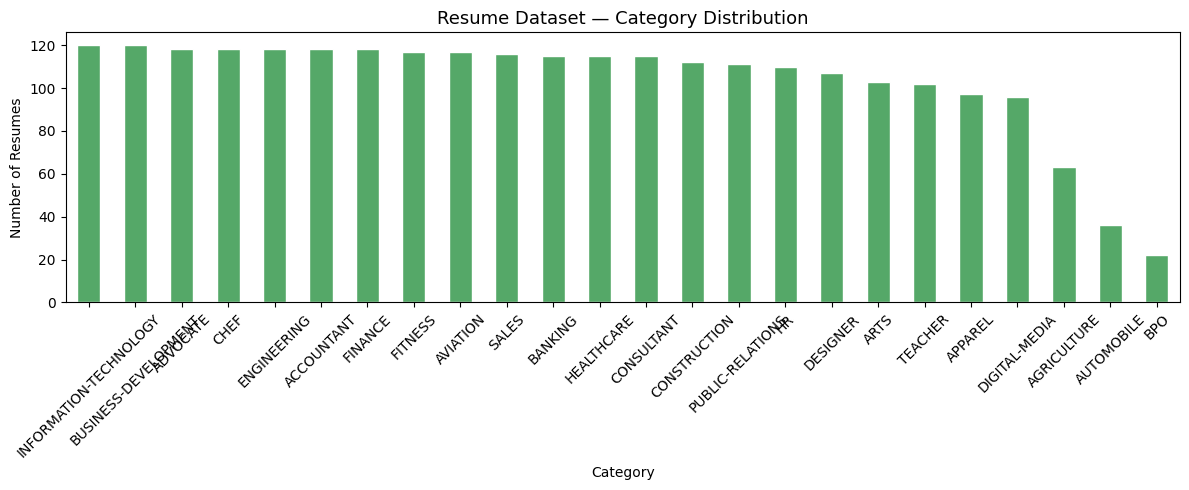


Total categories: 24
Min per category: 22  |  Max: 120
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


In [13]:
# ── Class distribution — Resume categories ────────────────────────────────
resume_cat_counts = resume_df[resume_category_col].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
resume_cat_counts.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Resume Dataset — Category Distribution", fontsize=13)
ax.set_xlabel("Category")
ax.set_ylabel("Number of Resumes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal categories: {resume_df[resume_category_col].nunique()}")
print(f"Min per category: {resume_cat_counts.min()}  |  Max: {resume_cat_counts.max()}")
print(resume_cat_counts.to_string())

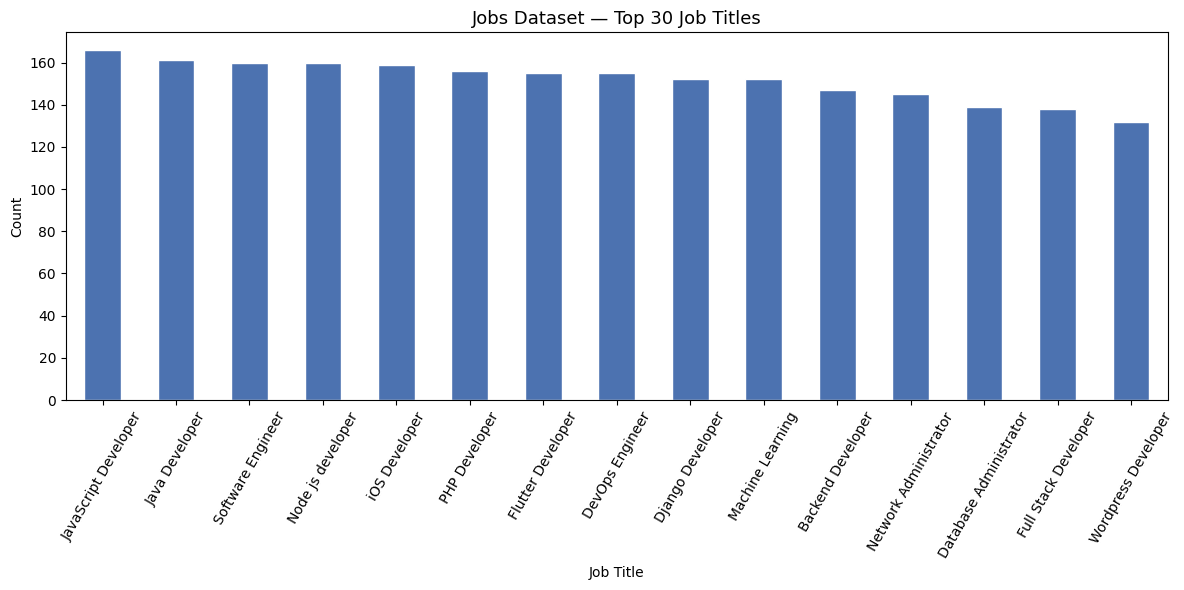


Total unique job titles: 15
Total JDs: 2,277


In [14]:
# ── Class distribution — Job titles (top 30) ──────────────────────────────
jobs_title_counts = jobs_df[jobs_title_col].value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 6))
jobs_title_counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Jobs Dataset — Top 30 Job Titles", fontsize=13)
ax.set_xlabel("Job Title")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

print(f"\nTotal unique job titles: {jobs_df[jobs_title_col].nunique()}")
print(f"Total JDs: {len(jobs_df):,}")

In [15]:
# ── Category overlap analysis ─────────────────────────────────────────────
# Normalize both label sets to lowercase for fuzzy matching
resume_cats = set(resume_df[resume_category_col].dropna().str.lower().str.strip())
jobs_titles  = set(jobs_df[jobs_title_col].dropna().str.lower().str.strip())

# Exact label matches
exact_overlap = resume_cats & jobs_titles

# Partial matches: resume category appears as substring of any job title (or vice versa)
partial_matches = []
for cat in resume_cats:
    for title in jobs_titles:
        if cat in title or title in cat:
            partial_matches.append((cat, title))

print(f"Resume categories  : {len(resume_cats)}")
print(f"Unique job titles   : {len(jobs_titles)}")
print(f"\nExact label overlaps: {len(exact_overlap)}")
if exact_overlap:
    for label in sorted(exact_overlap):
        print(f"  - {label}")

print(f"\nPartial string overlaps (resume cat ↔ job title): {len(partial_matches)}")
for cat, title in sorted(partial_matches)[:20]:
    print(f"  '{cat}'  ↔  '{title}'")

Resume categories  : 24
Unique job titles   : 15

Exact label overlaps: 0

Partial string overlaps (resume cat ↔ job title): 0


In [16]:
# ── Summary checkpoint ────────────────────────────────────────────────────
print("=" * 60)
print("DATASET SUMMARY — DECISION CHECKPOINT")
print("=" * 60)
print(f"Resumes   : {len(resume_df):,}  (target: ~2,400)")
print(f"JDs       : {len(jobs_df):,}")
print(f"Resume categories: {resume_df[resume_category_col].nunique()}")
print(f"JD titles        : {jobs_df[jobs_title_col].nunique()}")
print()

est_evidence     = len(resume_df) * 5
est_requirements = len(jobs_df) * 5
print(f"Estimated evidence sentences  (~5/resume): {est_evidence:,}")
print(f"Estimated requirement sentences (~5/JD)  : {est_requirements:,}")
print()
est_positive_pairs = int(est_evidence * 0.05)
est_negatives      = int(est_positive_pairs * 0.5)
print(f"Target positive pairs  (conservative est.): ~{est_positive_pairs:,}")
print(f"Target hard negatives  (conservative est.): ~{est_negatives:,}")
print()
print("→ Proceed to Notebook 2: Data Preparation & Pair Construction.")

DATASET SUMMARY — DECISION CHECKPOINT
Resumes   : 2,484  (target: ~2,400)
JDs       : 2,277
Resume categories: 24
JD titles        : 15

Estimated evidence sentences  (~5/resume): 12,420
Estimated requirement sentences (~5/JD)  : 11,385

Target positive pairs  (conservative est.): ~621
Target hard negatives  (conservative est.): ~310

→ Proceed to Notebook 2: Data Preparation & Pair Construction.
